# Regression Lineaire — Prediction du prix median immobilier

**Modele** : Regression lineaire (OLS — Ordinary Least Squares)

$$\hat{y} = X \theta \quad \text{avec} \quad \theta = (X^T X)^{-1} X^T y$$

**Pipeline** :
1. Chargement des donnees nettoyees (imputees, sans outliers, normalisees Z-Score)
2. Analyse de colinearite et selection des features
3. Train/test split (70/30)
4. Entrainement du modele de regression lineaire
5. Evaluation de la precision via la **moyenne** et l'**ecart-type** des erreurs

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv('./datasets/amputed_normalized_housing_data.csv')
print(f"Shape : {df.shape}")
df.head()

Shape : (17601, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-1.315977,0.995320,1.83728,-0.622220,-1.156299,-1.161352,-1.168233,2.620165,352100.0,1.300935
1,-1.320967,0.995320,1.83728,-0.799883,-0.953182,-1.058970,-0.964205,1.477758,341300.0,1.300935
2,-1.320967,0.995320,1.83728,-0.474934,-0.750065,-1.047410,-0.769893,0.206130,342200.0,1.300935
3,-1.320967,0.995320,1.83728,-1.126674,-1.052484,-1.298413,-1.090508,0.341013,269700.0,1.300935
4,-1.320967,0.990705,1.83728,0.360912,0.193300,-0.173855,0.468851,0.073723,299200.0,1.300935


## Observation de la linearite — Feature vs Prix median

Avant de construire un modele lineaire, on visualise la relation entre chaque feature numerique et la cible (`median_house_value`).  
Une **droite de regression** est superposee pour evaluer visuellement si la relation est lineaire. Le coefficient de correlation $r$ est affiche pour chaque graphique.

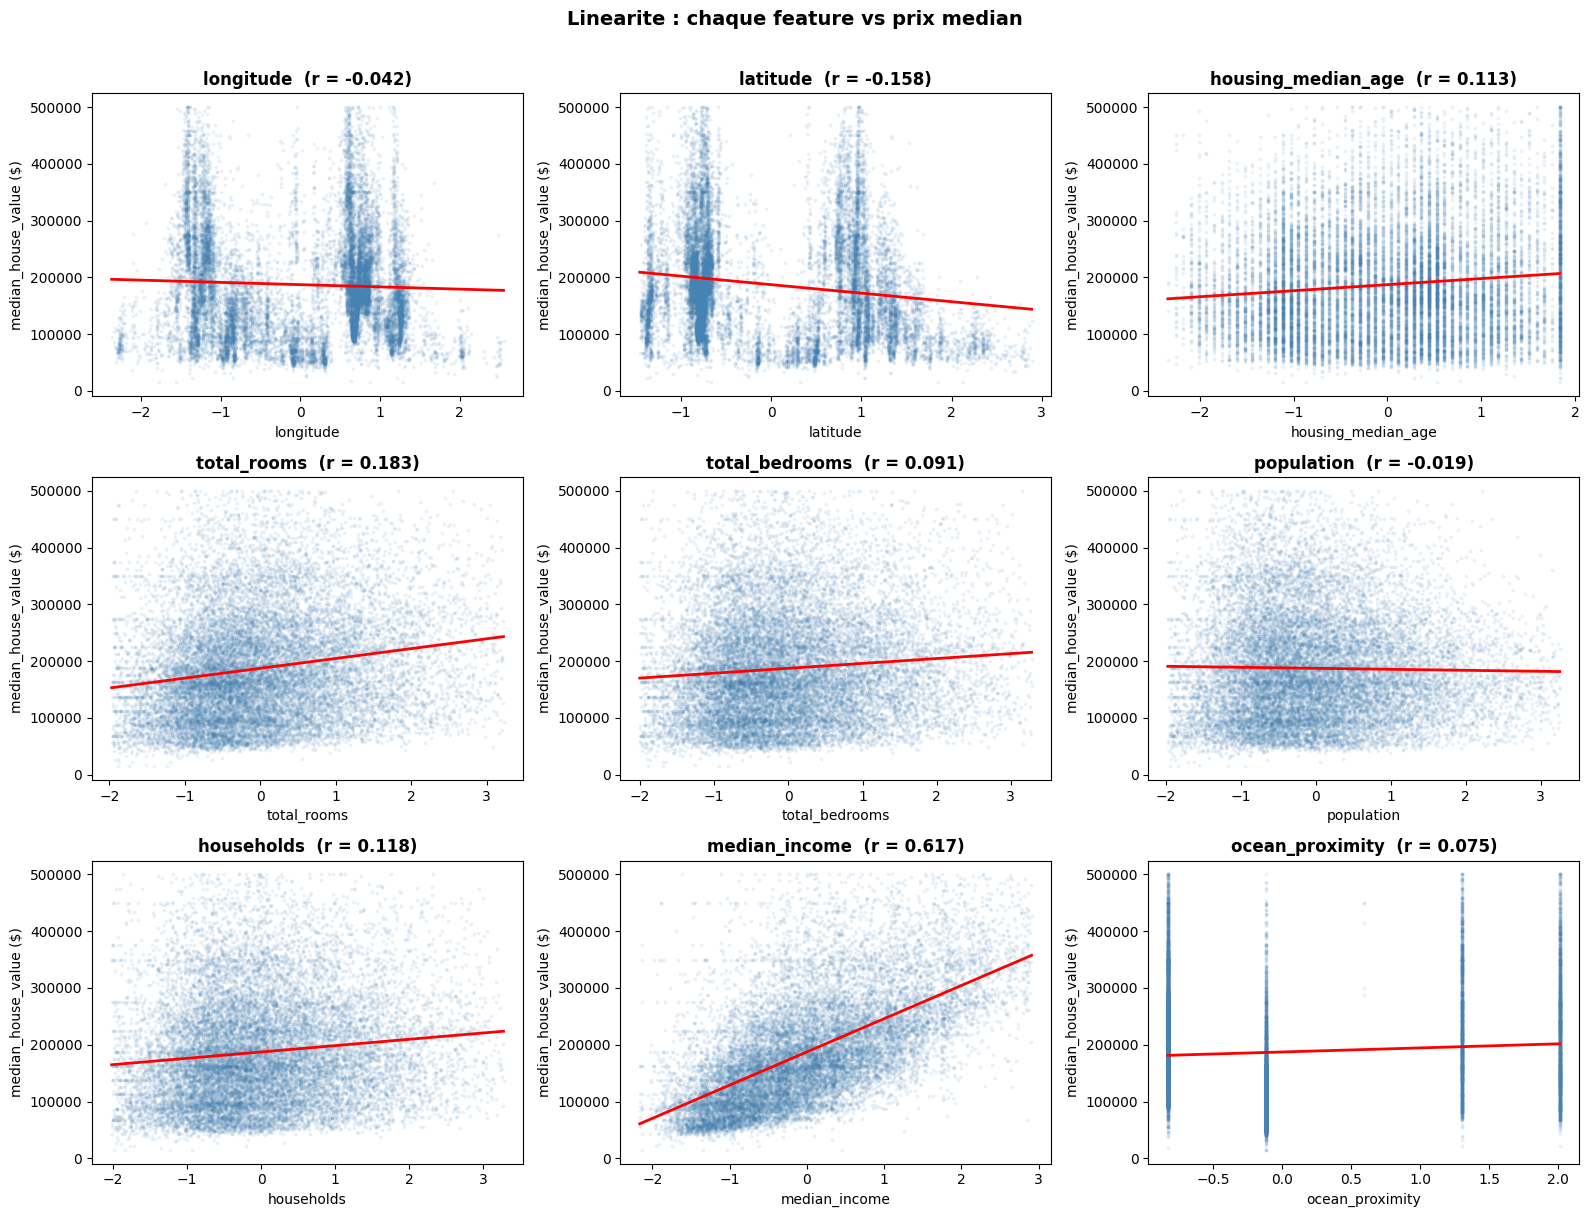

In [25]:
target = 'median_house_value'
num_features = [c for c in df.columns if c != target]

n = len(num_features)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    ax = axes[i]
    x = df[feat]
    y = df[target]
    
    # Scatter
    ax.scatter(x, y, alpha=0.08, s=3, color='steelblue')
    
    # Droite de regression
    coefs = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(coefs, x_line), 'r-', lw=2)
    
    # Coefficient de correlation
    r = np.corrcoef(x, y)[0, 1]
    ax.set_title(f'{feat}  (r = {r:.3f})', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('median_house_value ($)')

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Linearite : chaque feature vs prix median', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1. Analyse de colinearite

On identifie les paires de features avec $|r| > 0.8$ (fortement correlees).  
Pour chaque paire, on supprime la feature la moins correlee avec la cible.

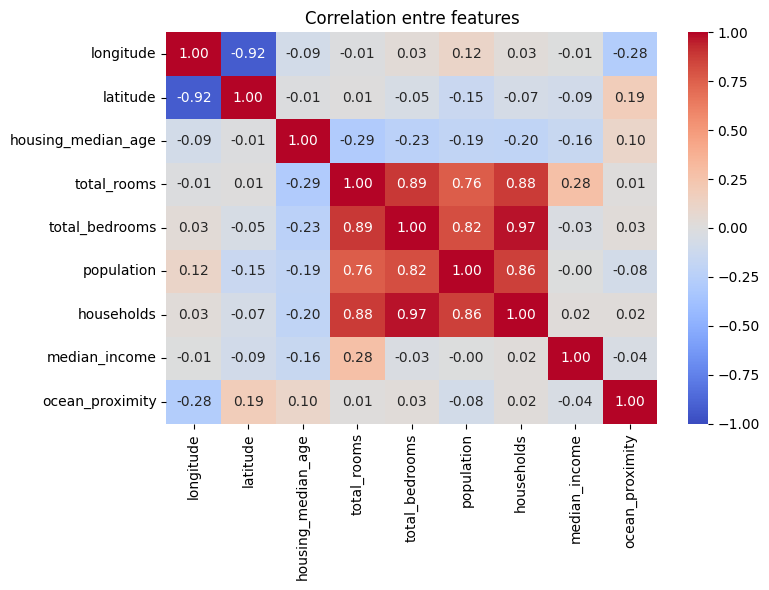


Paires avec |r| > 0.8 :
  longitude <-> latitude : r = -0.923
  total_rooms <-> total_bedrooms : r = 0.888
  total_rooms <-> households : r = 0.880
  total_bedrooms <-> population : r = 0.820
  total_bedrooms <-> households : r = 0.971
  population <-> households : r = 0.860


In [26]:
target = 'median_house_value'
features = [c for c in df.columns if c != target]

corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation entre features')
plt.tight_layout()
plt.show()

# Paires fortement correlees
threshold = 0.8
pairs = []
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        if abs(corr.iloc[i, j]) > threshold:
            pairs.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))

print(f"\nPaires avec |r| > {threshold} :")
for a, b, r in pairs:
    print(f"  {a} <-> {b} : r = {r:.3f}")

In [27]:
# Suppression des features redondantes
target_corr = df[features].corrwith(df[target]).abs()

to_drop = set()
for a, b, r in pairs:
    drop = a if target_corr[a] < target_corr[b] else b
    to_drop.add(drop)
    print(f"  {a} (|r_target|={target_corr[a]:.3f}) vs {b} (|r_target|={target_corr[b]:.3f}) -> drop {drop}")

features_clean = [f for f in features if f not in to_drop]
print(f"\nFeatures conservees ({len(features_clean)}) : {features_clean}")
print(f"Features supprimees ({len(to_drop)}) : {to_drop}")

  longitude (|r_target|=0.042) vs latitude (|r_target|=0.158) -> drop longitude
  total_rooms (|r_target|=0.183) vs total_bedrooms (|r_target|=0.091) -> drop total_bedrooms
  total_rooms (|r_target|=0.183) vs households (|r_target|=0.118) -> drop households
  total_bedrooms (|r_target|=0.091) vs population (|r_target|=0.019) -> drop population
  total_bedrooms (|r_target|=0.091) vs households (|r_target|=0.118) -> drop total_bedrooms
  population (|r_target|=0.019) vs households (|r_target|=0.118) -> drop population

Features conservees (5) : ['latitude', 'housing_median_age', 'total_rooms', 'median_income', 'ocean_proximity']
Features supprimees (4) : {'households', 'population', 'total_bedrooms', 'longitude'}


## 2. Train / Test split (70/30)

In [28]:
X = df[features_clean].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train : {X_train.shape[0]} echantillons ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} echantillons ({X_test.shape[0]/len(X)*100:.0f}%)")

Train : 12320 echantillons (70%)
Test  : 5281 echantillons (30%)


## 3. Regression lineaire

Le modele apprend les coefficients $\theta$ qui minimisent l'erreur quadratique moyenne :

$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - X_i \theta)^2$$

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients du modele :")
for name, coef in zip(features_clean, model.coef_):
    print(f"  {name:25s} : {coef:>12.2f}")
print(f"  {'(intercept)':25s} : {model.intercept_:>12.2f}")

Coefficients du modele :
  latitude                  :    -11116.21
  housing_median_age        :     21122.76
  total_rooms               :      7517.67
  median_income             :     59860.20
  ocean_proximity           :      9787.16
  (intercept)               :    186898.40


## 4. Predictions

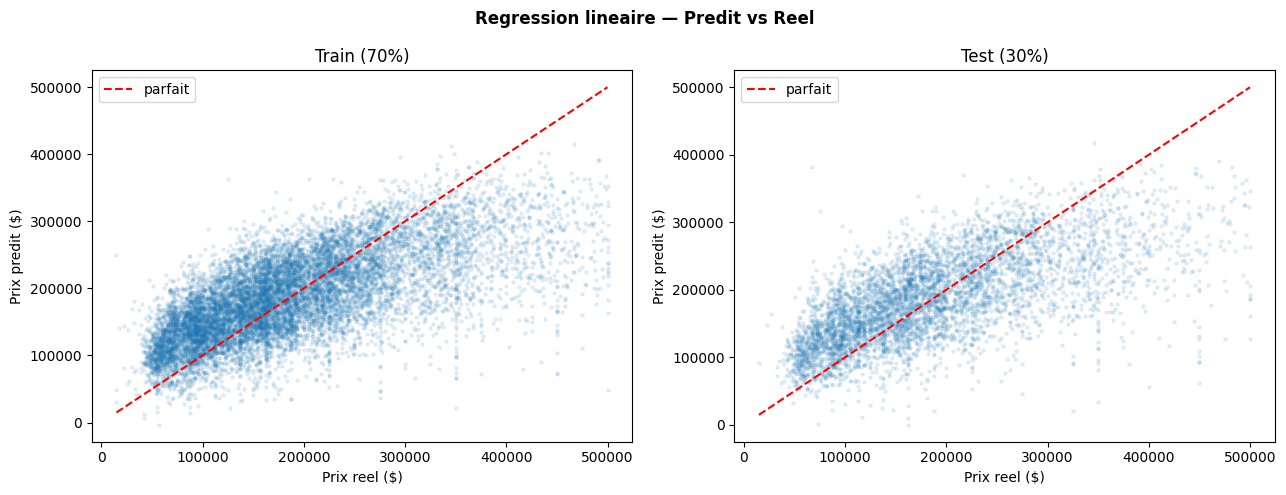

In [30]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Scatter plot : predit vs reel
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, y_true, y_pred) in zip(axes, [('Train (70%)', y_train, y_pred_train), ('Test (30%)', y_test, y_pred_test)]):
    ax.scatter(y_true, y_pred, alpha=0.1, s=5)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=1.5, label='parfait')
    ax.set_xlabel('Prix reel ($)')
    ax.set_ylabel('Prix predit ($)')
    ax.set_title(f'{name}')
    ax.legend()
plt.suptitle('Regression lineaire — Predit vs Reel', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Evaluation de la precision — Moyenne et ecart-type des erreurs (en %)

On evalue la qualite du modele en analysant la **distribution des erreurs relatives** (residus en pourcentage) :

$$e_{\%,i} = \frac{y_i - \hat{y}_i}{y_i} \times 100$$

| Metrique | Formule | Interpretation |
|----------|---------|----------------|
| **Moyenne des erreurs (%)** | $\bar{e}_\% = \frac{1}{n}\sum \frac{e_i}{y_i} \times 100$ | Biais relatif du modele (0% = pas de biais systematique) |
| **Ecart-type des erreurs (%)** | $\sigma_{e\%} = \text{std}\left(\frac{e_i}{y_i} \times 100\right)$ | Dispersion relative des erreurs (plus bas = plus precis) |

In [31]:
def evaluer_erreurs(y_true, y_pred, nom):
    """Calcule et affiche la moyenne et l'ecart-type des erreurs en pourcentage."""
    erreurs_pct = ((y_true - y_pred) / y_true) * 100
    
    moyenne = np.mean(erreurs_pct)
    ecart_type = np.std(erreurs_pct)
    
    print(f"--- {nom} ---")
    print(f"  Moyenne des erreurs (biais)      : {moyenne:>+8.2f} %")
    print(f"  Ecart-type des erreurs (spread)   : {ecart_type:>8.2f} %")
    print(f"  Intervalle 68% (1 sigma)          : [{moyenne - ecart_type:>+.2f}%, {moyenne + ecart_type:>+.2f}%]")
    print(f"  Intervalle 95% (2 sigma)          : [{moyenne - 2*ecart_type:>+.2f}%, {moyenne + 2*ecart_type:>+.2f}%]")
    print()
    
    return erreurs_pct, moyenne, ecart_type

err_train, mu_train, std_train = evaluer_erreurs(y_train, y_pred_train, 'Train (70%)')
err_test, mu_test, std_test = evaluer_erreurs(y_test, y_pred_test, 'Test (30%)')

--- Train (70%) ---
  Moyenne des erreurs (biais)      :   -15.58 %
  Ecart-type des erreurs (spread)   :    48.94 %
  Intervalle 68% (1 sigma)          : [-64.53%, +33.36%]
  Intervalle 95% (2 sigma)          : [-113.47%, +82.30%]

--- Test (30%) ---
  Moyenne des erreurs (biais)      :   -14.74 %
  Ecart-type des erreurs (spread)   :    47.61 %
  Intervalle 68% (1 sigma)          : [-62.36%, +32.87%]
  Intervalle 95% (2 sigma)          : [-109.97%, +80.48%]



### Interpretation

- **Moyenne proche de 0%** : le modele ne surestime ni ne sous-estime systematiquement les prix.
- **Ecart-type** : mesure la precision effective du modele en %. Un ecart-type faible signifie que les predictions sont regroupees autour de la vraie valeur.
- **Intervalle a 1 sigma** : 68% des predictions ont une erreur relative dans cet intervalle.
- **Intervalle a 2 sigma** : 95% des predictions ont une erreur relative dans cet intervalle.

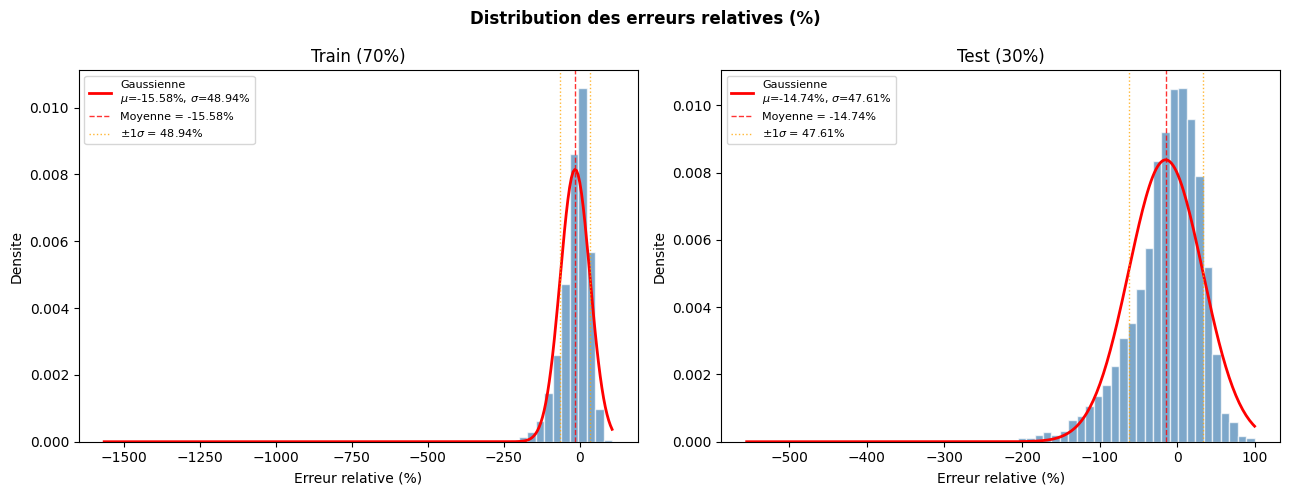

In [32]:
# Distribution des erreurs relatives (%)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (nom, erreurs, mu, sigma) in zip(axes, [
    ('Train (70%)', err_train, mu_train, std_train),
    ('Test (30%)', err_test, mu_test, std_test)
]):
    ax.hist(erreurs, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    
    # Courbe gaussienne theorique
    x = np.linspace(erreurs.min(), erreurs.max(), 300)
    gauss = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    ax.plot(x, gauss, 'r-', lw=2, label=f'Gaussienne\n$\\mu$={mu:.2f}%, $\\sigma$={sigma:.2f}%')
    
    # Lignes verticales pour mu et sigma
    ax.axvline(mu, color='red', linestyle='--', lw=1, alpha=0.8, label=f'Moyenne = {mu:.2f}%')
    ax.axvline(mu - sigma, color='orange', linestyle=':', lw=1, alpha=0.8)
    ax.axvline(mu + sigma, color='orange', linestyle=':', lw=1, alpha=0.8, label=f'$\\pm 1\\sigma$ = {sigma:.2f}%')
    
    ax.set_xlabel('Erreur relative (%)')
    ax.set_ylabel('Densite')
    ax.set_title(f'{nom}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des erreurs relatives (%)', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Resume des resultats

Tableau recapitulatif avec les metriques de precision basees sur la **moyenne** et l'**ecart-type** des erreurs, ainsi que le **coefficient de determination** $R^2$ :

$$R^2 = 1 - \frac{V(\text{reel})}{V(\text{theorique})} = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

| Variable | Description |
|----------|-------------|
| $V(\text{reel}) = \sum(y_i - \hat{y}_i)^2$ | Variance residuelle : erreur reelle du modele (somme des carres des ecarts entre valeurs observees et predites) |
| $V(\text{theorique}) = \sum(y_i - \bar{y})^2$ | Variance totale theorique : dispersion totale des donnees autour de la moyenne (le pire modele possible = toujours predire $\bar{y}$) |
| $y_i$ | Valeur reelle (prix median observe) pour l'echantillon $i$ |
| $\hat{y}_i$ | Valeur predite par le modele pour l'echantillon $i$ |
| $\bar{y}$ | Moyenne des valeurs reelles : $\bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i$ |
| $n$ | Nombre total d'echantillons |

- $R^2 = 1$ : $V(\text{reel}) = 0$, le modele predit parfaitement (aucune erreur)
- $R^2 = 0$ : $V(\text{reel}) = V(\text{theorique})$, le modele ne fait pas mieux que predire la moyenne $\bar{y}$
- $R^2 < 0$ : $V(\text{reel}) > V(\text{theorique})$, le modele fait pire que la moyenne

In [33]:
resume = pd.DataFrame({
    'Train': {
        'Moyenne erreurs (%)': mu_train,
        'Ecart-type erreurs (%)': std_train,
        'MAE ($)': mean_absolute_error(y_train, y_pred_train),
        'RMSE ($)': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'R2': r2_score(y_train, y_pred_train),
    },
    'Test': {
        'Moyenne erreurs (%)': mu_test,
        'Ecart-type erreurs (%)': std_test,
        'MAE ($)': mean_absolute_error(y_test, y_pred_test),
        'RMSE ($)': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'R2': r2_score(y_test, y_pred_test),
    }
})

print(resume.to_string(float_format=lambda x: f'{x:.2f}'))

print(f"\n--- Conclusion ---")
print(f"Le modele de regression lineaire a un ecart-type d'erreur de {std_test:.2f}% sur le jeu de test.")
print(f"Cela signifie que 68% des predictions sont a +/- {std_test:.2f}% du prix reel,")
print(f"et 95% des predictions sont a +/- {2*std_test:.2f}% du prix reel.")

                          Train     Test
Moyenne erreurs (%)      -15.58   -14.74
Ecart-type erreurs (%)    48.94    47.61
MAE ($)                53067.70 53955.97
RMSE ($)               69817.94 71640.94
R2                         0.46     0.43

--- Conclusion ---
Le modele de regression lineaire a un ecart-type d'erreur de 47.61% sur le jeu de test.
Cela signifie que 68% des predictions sont a +/- 47.61% du prix reel,
et 95% des predictions sont a +/- 95.23% du prix reel.


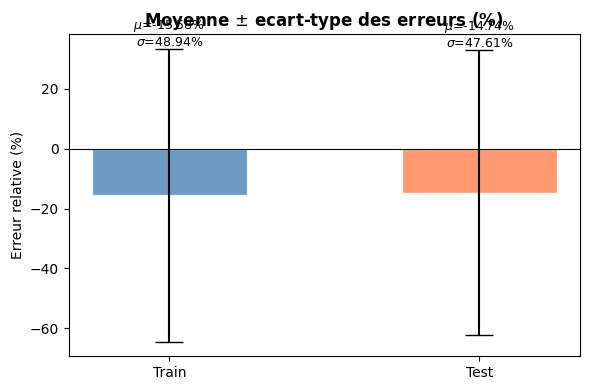

In [34]:
# Graphique de synthese : erreur moyenne +/- ecart-type (%) pour train et test
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['Train', 'Test']
moyennes = [mu_train, mu_test]
ecarts = [std_train, std_test]

x_pos = range(len(labels))
bars = ax.bar(x_pos, moyennes, yerr=ecarts, capsize=10, color=['steelblue', 'coral'], 
              edgecolor='white', alpha=0.8, width=0.5)

ax.axhline(0, color='black', linestyle='-', lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Erreur relative (%)')
ax.set_title('Moyenne $\\pm$ ecart-type des erreurs (%)', fontweight='bold')

for i, (m, s) in enumerate(zip(moyennes, ecarts)):
    ax.text(i, m + s + 1, f'$\\mu$={m:.2f}%\n$\\sigma$={s:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()